<a href="https://colab.research.google.com/github/bbangsberg/Apple/blob/main/OrderBook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

           time  event_type  order_id  size    price  direction
0  34200.004241           1  16113575    18  5853300          1
1  34200.004261           1  16113584    18  5853200          1
2  34200.004447           1  16113594    18  5853100          1
3  34200.025552           1  16120456    18  5859100         -1
4  34200.025580           1  16120480    18  5859200         -1
(91997, 6)
event
2    22506
1    21750
6    21048
5    20425
4     3320
3     2948
Name: count, dtype: int64
     limit_bid  limit_ask  market_buy  market_sell  cancel_bid  cancel_ask
bar                                                                       
0          404        444          92          114         208         272
1          235        498         121          106         219         464
2          163        210          33           51         145         198
3          839        453          99          235         821         387
4          444        491          70          110       

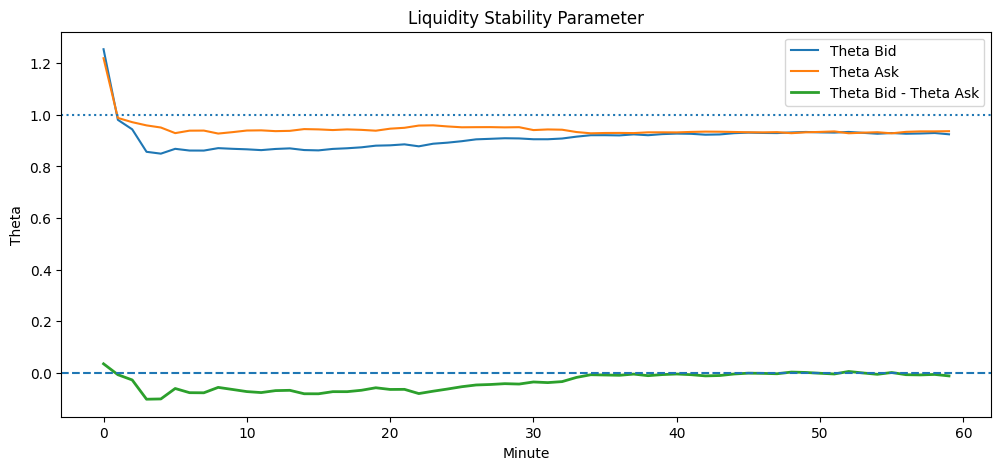

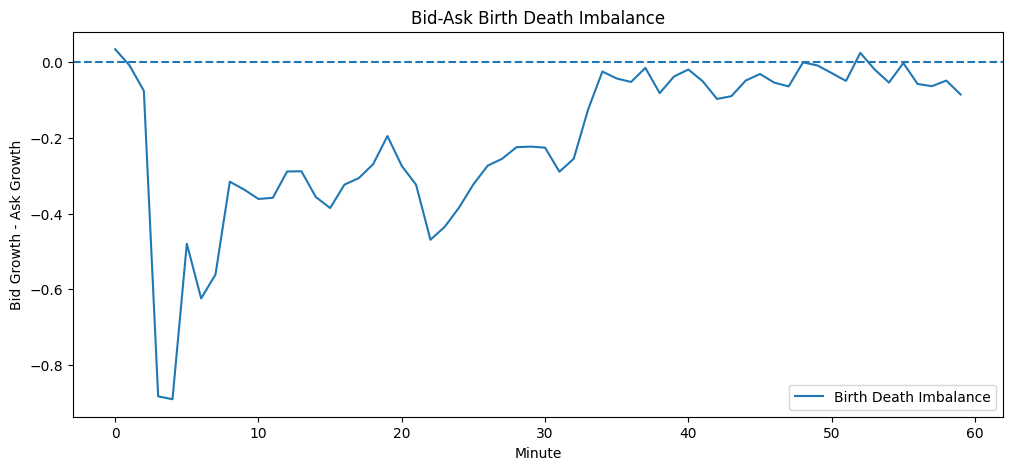

regime
Ask Stable    55
Bid Stable     5
Name: count, dtype: int64
     limit_bid  limit_ask  market_buy  market_sell  cancel_bid  cancel_ask  \
bar                                                                          
0          404        444          92          114         208         272   
1          235        498         121          106         219         464   
2          163        210          33           51         145         198   
3          839        453          99          235         821         387   
4          444        491          70          110         427         459   

     raw_limit_bid  raw_limit_ask  raw_market_buy  raw_market_sell  ...  \
bar                                                                 ...   
0         6.733333       7.400000        1.533333         1.900000  ...   
1         3.916667       8.300000        2.016667         1.766667  ...   
2         2.716667       3.500000        0.550000         0.850000  ...   
3        13

In [69]:
# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#BDI> 0 -> potential upward pressure
#BDI <0 -> potential downward pressure
# ============================================================
# 2. LOAD LOBSTER MESSAGE DATA
# ============================================================

url = "https://raw.githubusercontent.com/bbangsberg/Apple/02838f380bfe0dbaa3bb7f1696b0baa3a86bb792/AAPL_2012-06-21_34200000_37800000_message_50.csv"


df = pd.read_csv(
    url,
    header=None,
    names=[
        "time",
        "event_type",
        "order_id",
        "size",
        "price",
        "direction"
    ]
)


print(df.head())
print(df.shape)



# ============================================================
# 3. CONVERT TIME TO NANOSECONDS
# ============================================================

df["time_nanos"] = (
    df["time"] * 1e9
).astype(np.int64)



# ============================================================
# 4. CLASSIFY EVENTS
# ============================================================

# LOBSTER:
#
# 1 = submission
# 2 = cancellation
# 3 = deletion
# 4 = execution visible
# 5 = execution hidden
# 6 = trading halt
#
# Here:
#
# 1 = limit bid
# 2 = limit ask
# 3 = market buy
# 4 = market sell
# 5 = cancel bid
# 6 = cancel ask


def classify_event(row):

    event = row["event_type"]
    direction = row["direction"]


    # Limit order arrival

    if event == 1:

        if direction == 1:
            return 1   # bid limit

        else:
            return 2   # ask limit


    # Cancellation

    elif event in [2,3]:

        if direction == 1:
            return 5   # cancel bid

        else:
            return 6   # cancel ask



    # Execution

    elif event in [4,5]:

        if direction == 1:
            return 3   # market buy

        else:
            return 4   # market sell


    return np.nan



df["event"] = df.apply(
    classify_event,
    axis=1
)



df = df.dropna(
    subset=["event"]
)


df["event"] = df["event"].astype(int)



print(
    df["event"].value_counts()
)



# ============================================================
# 5. CREATE TIME BINS
# ============================================================


BAR_SECONDS = 60

BAR_SIZE = BAR_SECONDS * 1e9



df["bar"] = (
    df["time_nanos"]
    //
    BAR_SIZE
).astype(int)



# normalize starting bar

df["bar"] = (
    df["bar"]
    -
    df["bar"].min()
)




# ============================================================
# 6. EVENT COUNTS PER BAR
# ============================================================


event_counts = df.pivot_table(
    index="bar",
    columns="event",
    values="size",
    aggfunc="count",
    fill_value=0
)



# ensure six event types exist

for i in range(1,7):

    if i not in event_counts.columns:

        event_counts[i] = 0



event_counts = event_counts[
    [1,2,3,4,5,6]
]



event_counts.columns = [

    "limit_bid",
    "limit_ask",
    "market_buy",
    "market_sell",
    "cancel_bid",
    "cancel_ask"

]



print(event_counts.head())



# ============================================================
# 7. POISSON INTENSITIES
# ============================================================


intensity = (
    event_counts
    /
    BAR_SECONDS
)



intensity.head()



# ============================================================
# 8. EWMA SMOOTHING
# ============================================================

# λ̂_t =
#
#     α x_t
#
#     +
#
#     (1 − α) λ̂_(t−1)
#
#
# Purpose
#
#     Smooth noisy Poisson intensity estimates while allowing
#     recent order flow to receive greater weight.
#

alpha = 0.05



lambda_df = (
    intensity
    .ewm(alpha=alpha)
    .mean()
)



lambda_df.columns = [

    "lambda_limit_bid",
    "lambda_limit_ask",
    "lambda_market_buy",
    "lambda_market_sell",
    "lambda_cancel_bid",
    "lambda_cancel_ask"

]



# ============================================================
# 9. BIRTH-DEATH RATES
# ============================================================


# Bid:
#
# Births:
# limit bids
#
# Deaths:
# cancel bids + market sells

# Queue Growth
#
# dN
# -- = Birth − Death
# dt
#
#
# Bid Queue
#
# dN_bid
# ------- = λ_b − (δ_b + μ_a)
#   dt
#
#
# Ask Queue
#
# dN_ask
# ------- = λ_a − (δ_a + μ_b)
#   dt
#


lambda_df["bid_birth"] = (
    lambda_df["lambda_limit_bid"]
)


lambda_df["bid_death"] = (

    lambda_df["lambda_cancel_bid"]

    +

    lambda_df["lambda_market_sell"]

)



# Ask:
#
# Births:
# limit asks
#
# Deaths:
# cancel asks + market buys


lambda_df["ask_birth"] = (

    lambda_df["lambda_limit_ask"]

)



lambda_df["ask_death"] = (

    lambda_df["lambda_cancel_ask"]

    +

    lambda_df["lambda_market_buy"]

)



# ============================================================
# 10. QUEUE GROWTH RATE
# ============================================================


lambda_df["bid_growth"] = (

    lambda_df["bid_birth"]

    -

    lambda_df["bid_death"]

)



lambda_df["ask_growth"] = (

    lambda_df["ask_birth"]

    -

    lambda_df["ask_death"]

)



# ============================================================
# 11. THETA STABILITY PARAMETER
# ============================================================


epsilon = 1e-8


#
# theta = birth/death
#


lambda_df["theta_bid"] = (

    lambda_df["lambda_limit_bid"]

    /

    (lambda_df["bid_death"] + epsilon)

)



lambda_df["theta_ask"] = (

    lambda_df["lambda_limit_ask"]

    /

    (lambda_df["ask_death"] + epsilon)

)



# Relative stability

lambda_df["theta_imbalance"] = (

    lambda_df["theta_bid"]

    -

    lambda_df["theta_ask"]

)



# ============================================================
# 12. BIRTH-DEATH IMBALANCE
# ============================================================


lambda_df["birth_death_imbalance"] = (

    lambda_df["bid_growth"]

    -

    lambda_df["ask_growth"]

)



# ============================================================
# 13. PLOT THETA BID VS ASK
# ============================================================


plt.figure(figsize=(12,5))


plt.plot(
    lambda_df["theta_bid"],
    label="Theta Bid"
)


plt.plot(
    lambda_df["theta_ask"],
    label="Theta Ask"
)


plt.plot(
    lambda_df["theta_imbalance"],
    label="Theta Bid - Theta Ask",
    linewidth=2
)


plt.axhline(
    0,
    linestyle="--"
)


plt.axhline(
    1,
    linestyle=":"
)


plt.title(
    "Liquidity Stability Parameter"
)


plt.xlabel(
    "Minute"
)


plt.ylabel(
    "Theta"
)


plt.legend()

plt.show()



# ============================================================
# 14. PLOT BIRTH-DEATH IMBALANCE
# ============================================================


plt.figure(figsize=(12,5))


plt.plot(
    lambda_df["birth_death_imbalance"],
    label="Birth Death Imbalance"
)


plt.axhline(
    0,
    linestyle="--"
)



plt.title(
    "Bid-Ask Birth Death Imbalance"
)


plt.xlabel(
    "Minute"
)


plt.ylabel(
    "Bid Growth - Ask Growth"
)


plt.legend()

plt.show()



# ============================================================
# 15. REGIME CLASSIFICATION
# ============================================================


conditions = [

    lambda_df["theta_imbalance"] > 0,

    lambda_df["theta_imbalance"] < 0

]


choices = [

    "Bid Stable",

    "Ask Stable"

]



lambda_df["regime"] = np.select(

    conditions,

    choices,

    default="Balanced"

)



print(
    lambda_df["regime"].value_counts()
)



# ============================================================
# 16. FINAL DATASET
# ============================================================


final = pd.concat(

    [

        event_counts,

        intensity.add_prefix("raw_"),

        lambda_df

    ],

    axis=1

)



print(final.head())

In [70]:
#Part 2:

book_url = "https://raw.githubusercontent.com/bbangsberg/Apple/refs/heads/main/AAPL_2012-06-21_34200000_57600000_orderbook_66.csv"


book = pd.read_csv(
    book_url,
    header=None
)

book = pd.read_csv(
    book_url,
    header=None
)

print(book.shape)
print(book.head())

(167759, 20)
        0    1        2   3        4    5        6    7        8    9   \
0  5859400  200  5853300  18  5859800  200  5853000  150  5861000  200   
1  5859400  200  5853300  18  5859800  200  5853200   18  5861000  200   
2  5859400  200  5853300  18  5859800  200  5853200   18  5861000  200   
3  5859100   18  5853300  18  5859400  200  5853200   18  5859800  200   
4  5859100   18  5853300  18  5859200   18  5853200   18  5859400  200   

        10   11       12   13       14   15       16   17       18  19  
0  5851000    5  5868900  300  5850100   89  5869500   50  5849700   5  
1  5853000  150  5868900  300  5851000    5  5869500   50  5850100  89  
2  5853100   18  5868900  300  5853000  150  5869500   50  5851000   5  
3  5853100   18  5861000  200  5853000  150  5868900  300  5851000   5  
4  5853100   18  5859800  200  5853000  150  5861000  200  5851000   5  


In [71]:
book["ask_price_1"] = book[0] / 10000

book["ask_size_1"] = book[1]

book["bid_price_1"] = book[2] / 10000

book["bid_size_1"] = book[3]

In [72]:
book.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,ask_price_1,ask_size_1,bid_price_1,bid_size_1
0,5859400,200,5853300,18,5859800,200,5853000,150,5861000,200,...,5850100,89,5869500,50,5849700,5,585.94,200,585.33,18
1,5859400,200,5853300,18,5859800,200,5853200,18,5861000,200,...,5851000,5,5869500,50,5850100,89,585.94,200,585.33,18
2,5859400,200,5853300,18,5859800,200,5853200,18,5861000,200,...,5853000,150,5869500,50,5851000,5,585.94,200,585.33,18
3,5859100,18,5853300,18,5859400,200,5853200,18,5859800,200,...,5853000,150,5868900,300,5851000,5,585.91,18,585.33,18
4,5859100,18,5853300,18,5859200,18,5853200,18,5859400,200,...,5853000,150,5861000,200,5851000,5,585.91,18,585.33,18


In [73]:
book.columns

Index([            0,             1,             2,             3,
                   4,             5,             6,             7,
                   8,             9,            10,            11,
                  12,            13,            14,            15,
                  16,            17,            18,            19,
       'ask_price_1',  'ask_size_1', 'bid_price_1',  'bid_size_1'],
      dtype='object')

In [74]:
#tick by tick midprice
book["mid_price"] = (

    book["bid_price_1"]

    +

    book["ask_price_1"]

) / 2

In [75]:
book["time"] = df["time"]
#tick by tick midprice

In [76]:
book.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,ask_price_1,ask_size_1,bid_price_1,bid_size_1,mid_price,time
0,5859400,200,5853300,18,5859800,200,5853000,150,5861000,200,...,5869500,50,5849700,5,585.94,200,585.33,18,585.635,34200.004241
1,5859400,200,5853300,18,5859800,200,5853200,18,5861000,200,...,5869500,50,5850100,89,585.94,200,585.33,18,585.635,34200.004261
2,5859400,200,5853300,18,5859800,200,5853200,18,5861000,200,...,5869500,50,5851000,5,585.94,200,585.33,18,585.635,34200.004447
3,5859100,18,5853300,18,5859400,200,5853200,18,5859800,200,...,5868900,300,5851000,5,585.91,18,585.33,18,585.620,34200.025552
4,5859100,18,5853300,18,5859200,18,5853200,18,5859400,200,...,5861000,200,5851000,5,585.91,18,585.33,18,585.620,34200.025580


In [77]:
'''book["time_nanos"] = (
    book["time"] * 1e9
).astype(np.int64)


book["bar"] = (

    book["time_nanos"]

    //

    BAR_SIZE

).astype(int)


book["bar"] -= book["bar"].min()'''

'book["time_nanos"] = (\n    book["time"] * 1e9\n).astype(np.int64)\n\n\nbook["bar"] = (\n\n    book["time_nanos"]\n\n    //\n\n    BAR_SIZE\n\n).astype(int)\n\n\nbook["bar"] -= book["bar"].min()'

In [78]:
book["time"].isna().sum()

np.int64(75762)

In [79]:
book = book.iloc[:len(df)].copy()

In [80]:
print(book.shape)
print(df.shape)

(91997, 26)
(91997, 9)


In [81]:
book["time"] = df["time"].values

In [82]:
book["time_nanos"] = (
    book["time"] * 1e9
).astype(np.int64)

In [83]:
book[
    [
        "bid_price_1",
        "ask_price_1"
    ]
].head()

,bid_price_1,ask_price_1
0,585.33,585.94
1,585.33,585.94
2,585.33,585.94
3,585.33,585.91
4,585.33,585.91


In [84]:
book["mid_price"] = (
    book["bid_price_1"]
    +
    book["ask_price_1"]
) / 2

In [85]:
book[
    [
        "bid_price_1",
        "ask_price_1",
        "mid_price"
    ]
].head()

,bid_price_1,ask_price_1,mid_price
0,585.33,585.94,585.635
1,585.33,585.94,585.635
2,585.33,585.94,585.635
3,585.33,585.91,585.620
4,585.33,585.91,585.620


In [86]:
book["time"] = df["time"].values

In [87]:
book["time_nanos"] = (
    book["time"] * 1e9
).astype(np.int64)

In [88]:
#minute bars
BAR_SECONDS = 60

book["bar"] = (
    book["time_nanos"]
    //
    (BAR_SECONDS * 1e9)
).astype(int)


book["bar"] -= book["bar"].min()

In [89]:
price_bar = book.groupby("bar").agg(

    mid_price_avg=(
        "mid_price",
        "mean"
    ),

    mid_price_last=(
        "mid_price",
        "last"
    ),

    bid_last=(
        "bid_price_1",
        "last"
    ),

    ask_last=(
        "ask_price_1",
        "last"
    )

)

In [90]:
price_bar.head()

,mid_price_avg,mid_price_last,bid_last,ask_last
bar,,,,
0,585.552419,585.530,585.44,585.62
1,585.105070,585.065,584.96,585.17
2,585.384444,585.595,585.41,585.78
3,586.634233,587.535,587.50,587.57
4,587.075862,587.315,587.13,587.50


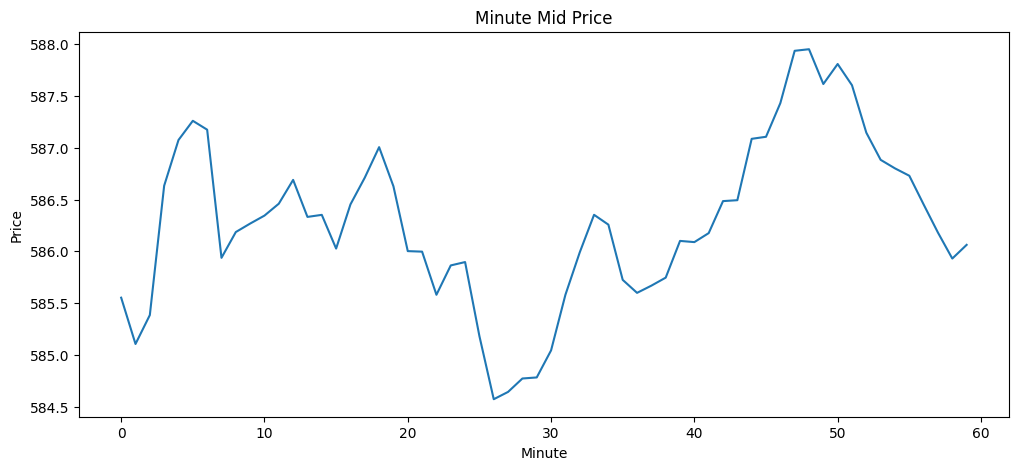

In [91]:
#plot price level
plt.figure(figsize=(12,5))

plt.plot(
    price_bar["mid_price_avg"]
)

plt.title(
    "Minute Mid Price"
)

plt.xlabel(
    "Minute"
)

plt.ylabel(
    "Price"
)

plt.show()

In [92]:
#spread = ask1 - bid1
price_bar["spread"] = (
    price_bar["ask_last"]
    -
    price_bar["bid_last"]
)

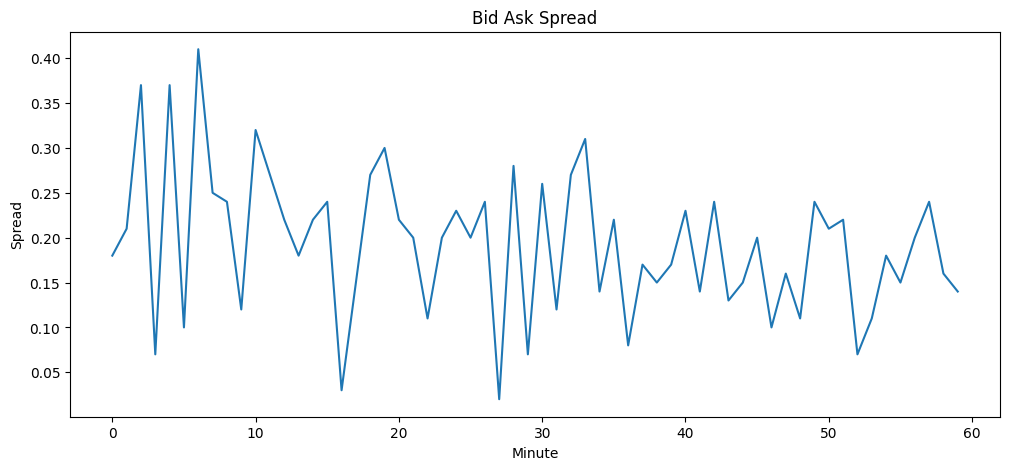

In [93]:
plt.figure(figsize=(12,5))

plt.plot(
    price_bar["spread"]
)

plt.title(
    "Bid Ask Spread"
)

plt.xlabel(
    "Minute"
)

plt.ylabel(
    "Spread"
)

plt.show()

In [94]:
#var data set
var_df = pd.concat(
    [
        price_bar["mid_price_avg"],
        lambda_df["birth_death_imbalance"]
    ],
    axis=1
)

In [95]:
#price change aka deltaP = P_t - P_t-1
'''
var_df["price_change"] = (
    var_df["price"]
    -
    var_df["price"].shift(1)
)'''

'\nvar_df["price_change"] = (\n    var_df["price"]\n    -\n    var_df["price"].shift(1)\n)'

In [96]:
var_df.columns

Index(['mid_price_avg', 'birth_death_imbalance'], dtype='object')

In [97]:
var_df = var_df.rename(
    columns={
        "mid_price_avg": "price",
        "birth_death_imbalance": "BDI"
    }
)

print(var_df.head())
print(var_df.columns)

          price       BDI
bar                      
0    585.552419  0.033333
1    585.105070 -0.009402
2    585.384444 -0.076220
3    586.634233 -0.882297
4    587.075862 -0.889894
Index(['price', 'BDI'], dtype='object')


In [98]:
var_df["price_change"] = (
    var_df["price"]
    -
    var_df["price"].shift(1)
)

In [99]:
var_df = var_df.dropna()

In [100]:
var_df.head()

,price,BDI,price_change
bar,,,
1,585.105070,-0.009402,-0.447349
2,585.384444,-0.076220,0.279374
3,586.634233,-0.882297,1.249789
4,587.075862,-0.889894,0.441630
5,587.261296,-0.479709,0.185434


In [101]:
print(var_df.shape)
print(var_df.isna().sum())

(59, 3)
price           0
BDI             0
price_change    0
dtype: int64


In [102]:
from statsmodels.tsa.stattools import adfuller

adf = adfuller(var_df["price_change"])

print("ADF statistic:", adf[0])
print("p-value:", adf[1])

ADF statistic: -5.872971522801375
p-value: 3.2079204715220697e-07


In [103]:
from statsmodels.tsa.api import VAR

model = VAR(
    var_df[
        [
            "price_change",
            "BDI"
        ]
    ]
)

results = model.fit(maxlags=5)

print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 27, Jul, 2026
Time:                     23:53:14
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -6.98650
Nobs:                     54.0000    HQIC:                  -7.48431
Log likelihood:           79.2688    FPE:                0.000415818
AIC:                     -7.79682    Det(Omega_mle):     0.000286988
--------------------------------------------------------------------
Results for equation price_change
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                  -0.031479         0.070999           -0.443           0.657
L1.price_change         0.167779         0.135049            1.242           0.214
L1.BDI                 -1.515745         0.85

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [104]:
#check stationarity

from statsmodels.tsa.stattools import adfuller

for col in ["price_change","BDI"]:

    result = adfuller(
        var_df[col]
    )

    print(col)
    print("ADF:", result[0])
    print("p-value:", result[1])
    print()

price_change
ADF: -5.872971522801375
p-value: 3.2079204715220697e-07

BDI
ADF: -2.6576054958327147
p-value: 0.08166602212378526



In [105]:
# because p value of 3.2*10^-7 is < 0.05, we can reject the null hypothesis that H_0 exists, meaning that the change in price (deltaP) is stationary

In [106]:
#because BDI = 0.087 > 0.05, we do not reject the null hypothesis at this level
#however, on the 10% level, 0.087 < 0.1, and so it si weakly stationary

# -> so, birth-death imbalance may have persistence/trending behavior

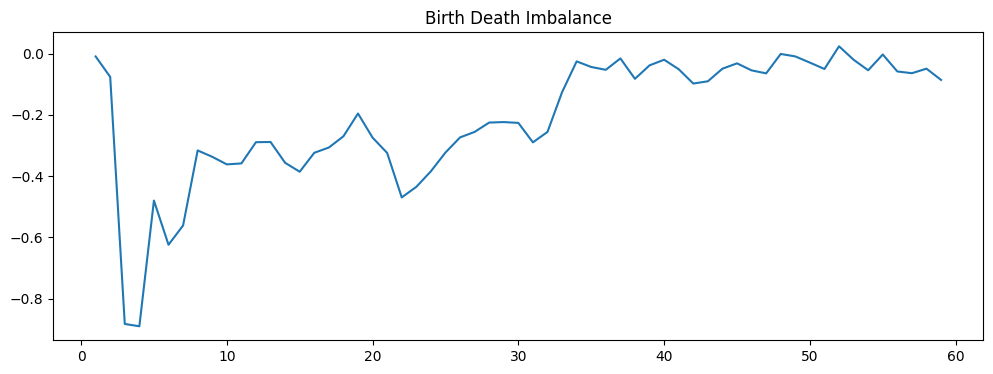

In [107]:
plt.figure(figsize=(12,4))

plt.plot(
    var_df["BDI"]
)

plt.title("Birth Death Imbalance")

plt.show()

In [108]:
var_df["BDI"].describe()

,BDI
count,59.000000
mean,-0.212218
std,0.205457
min,-0.889894
25%,-0.323423
50%,-0.195691
75%,-0.049890
max,0.023721


In [109]:
var_df["BDI_change"] = (
    var_df["BDI"]
    -
    var_df["BDI"].shift(1)
)

var_df["BDI_change"].describe()

,BDI_change
count,58.000000
mean,-0.001322
std,0.134921
min,-0.806078
25%,-0.030479
50%,0.001087
75%,0.043231
max,0.410185


In [110]:
from statsmodels.tsa.stattools import adfuller

adfuller(
    var_df["BDI_change"].dropna()
)

(np.float64(-14.98687466231943),
 np.float64(1.1404107191684797e-27),
 1,
 56,
 {'1%': np.float64(-3.552928203580539),
  '5%': np.float64(-2.9147306250000002),
  '10%': np.float64(-2.595137155612245)},
 np.float64(-138.52118775776052))

In [111]:
lambda_df["normalized_BDI"] = (

    lambda_df["bid_growth"]
    -
    lambda_df["ask_growth"]

) / (

    abs(lambda_df["bid_growth"])
    +
    abs(lambda_df["ask_growth"])
    +
    1e-8

)

In [112]:
var_df["BDI"].describe()

,BDI
count,59.000000
mean,-0.212218
std,0.205457
min,-0.889894
25%,-0.323423
50%,-0.195691
75%,-0.049890
max,0.023721


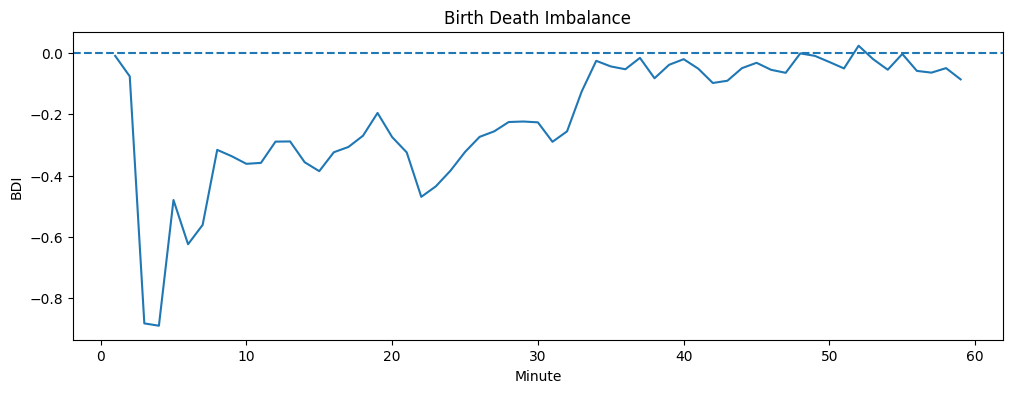

In [113]:
plt.figure(figsize=(12,4))

plt.plot(var_df["BDI"])

plt.axhline(0, linestyle="--")

plt.title("Birth Death Imbalance")

plt.xlabel("Minute")

plt.ylabel("BDI")

plt.show()

In [114]:
lambda_df[
    [
        "bid_growth",
        "ask_growth",
        "birth_death_imbalance"
    ]
].describe()

,bid_growth,ask_growth,birth_death_imbalance
count,60.000000,60.000000,60.000000
mean,-0.588675,-0.380550,-0.208126
std,0.315782,0.244212,0.206160
min,-1.249919,-0.554806,-0.889894
25%,-0.685150,-0.483382,-0.323209
50%,-0.587540,-0.402617,-0.160882
75%,-0.515484,-0.345312,-0.049417
max,1.366667,1.333333,0.033333


In [115]:
lambda_df["normalized_BDI"] = (

    lambda_df["bid_growth"]
    -
    lambda_df["ask_growth"]

) / (

    abs(lambda_df["bid_growth"])
    +
    abs(lambda_df["ask_growth"])
    +
    1e-8

)

In [116]:
var_df = pd.concat(
    [
        price_bar["mid_price_avg"],
        lambda_df["normalized_BDI"]
    ],
    axis=1
)

var_df.columns = [
    "price",
    "BDI"
]

var_df["price_change"] = (
    var_df["price"]
    -
    var_df["price"].shift(1)
)

var_df = var_df.dropna()

In [117]:
model = VAR(
    var_df[
        [
            "price_change",
            "BDI"
        ]
    ]
)

results = model.fit(1)

print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 27, Jul, 2026
Time:                     23:53:15
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -6.62695
Nobs:                     58.0000    HQIC:                  -6.75707
Log likelihood:           39.7659    FPE:                 0.00107020
AIC:                     -6.84010    Det(Omega_mle):     0.000967520
--------------------------------------------------------------------
Results for equation price_change
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.031486         0.078969            0.399           0.690
L1.price_change         0.253909         0.130075            1.952           0.051
L1.BDI                  0.085398         0.31

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [118]:
var_df = pd.concat(
    [
        price_bar["mid_price_avg"],
        lambda_df["birth_death_imbalance"]
    ],
    axis=1
)

var_df.columns = [
    "price",
    "BDI"
]

In [119]:
var_df["price_change"] = (
    var_df["price"]
    -
    var_df["price"].shift(1)
)

var_df = var_df.dropna()

In [120]:
var_df.head()

,price,BDI,price_change
bar,,,
1,585.105070,-0.009402,-0.447349
2,585.384444,-0.076220,0.279374
3,586.634233,-0.882297,1.249789
4,587.075862,-0.889894,0.441630
5,587.261296,-0.479709,0.185434


In [121]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=var_df)

https://docs.google.com/spreadsheets/d/1cozGwXnw8KXJBq2kFjBEVyTCrQt6YwG7ExUIznVVWXQ/edit#gid=0


In [122]:
from statsmodels.tsa.stattools import adfuller


for col in ["price_change", "BDI"]:

    result = adfuller(
        var_df[col]
    )

    print(col)
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    print()

price_change
ADF statistic: -5.872971522801375
p-value: 3.2079204715220697e-07

BDI
ADF statistic: -2.6576054958327147
p-value: 0.08166602212378526



In [123]:
from statsmodels.tsa.api import VAR


model = VAR(
    var_df[
        [
            "price_change",
            "BDI"
        ]
    ]
)


results = model.fit(
    maxlags=1
)


print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 27, Jul, 2026
Time:                     23:53:17
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -5.81421
Nobs:                     58.0000    HQIC:                  -5.94433
Log likelihood:           16.1965    FPE:                 0.00241231
AIC:                     -6.02736    Det(Omega_mle):      0.00218087
--------------------------------------------------------------------
Results for equation price_change
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.043652         0.072408            0.603           0.547
L1.price_change         0.262476         0.130926            2.005           0.045
L1.BDI                  0.134571         0.24

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [124]:
correct = 0
total = 0

predictions = []
actuals = []


for i in range(30, len(var_df)-5):

    train = var_df.iloc[:i]


    model = VAR(
        train[
            [
                "price_change",
                "BDI"
            ]
        ]
    )

    fitted = model.fit(1)


    forecast = fitted.forecast(
        train[
            [
                "price_change",
                "BDI"
            ]
        ].values[-1:],
        steps=5
    )


    predicted_return = forecast[:,0].sum()

    predicted_direction = np.sign(
        predicted_return
    )


    actual_return = (
        var_df["price"].iloc[i+5]
        -
        var_df["price"].iloc[i]
    )

    actual_direction = np.sign(
        actual_return
    )


    predictions.append(
        predicted_direction
    )

    actuals.append(
        actual_direction
    )


    if predicted_direction == actual_direction:
        correct += 1


    total += 1


accuracy = correct / total

print(
    "Directional accuracy:",
    accuracy
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

Directional accuracy: 0.5416666666666666


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [125]:
#Accuracy = 0.54 > 50%

In [126]:
#L.BDI in regression summary (BDI) = 0.134571 > 0

In [127]:
from statsmodels.tsa.api import VAR
import numpy as np


correct = 0
total = 0

predictions = []
actuals = []


for i in range(30, len(var_df)-5):

    # training window
    train = var_df.iloc[:i]


    model = VAR(
        train[
            [
                "price_change",
                "BDI"
            ]
        ]
    )


    fitted = model.fit(1)


    # forecast next 5 minutes
    forecast = fitted.forecast(
        train[
            [
                "price_change",
                "BDI"
            ]
        ].values[-1:],
        steps=5
    )


    # sum predicted returns over 5 minutes
    predicted_return = forecast[:,0].sum()


    predicted_direction = np.sign(
        predicted_return
    )


    # actual 5-minute forward return
    actual_return = (
        var_df["price"].iloc[i+5]
        -
        var_df["price"].iloc[i]
    )


    actual_direction = np.sign(
        actual_return
    )


    predictions.append(
        predicted_direction
    )

    actuals.append(
        actual_direction
    )


    if predicted_direction == actual_direction:
        correct += 1


    total += 1



accuracy = correct / total


print("Correct:", correct)
print("Total:", total)
print("Directional accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

Correct: 13
Total: 24
Directional accuracy: 0.5416666666666666


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

In [128]:
#price momentum only

from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(
    var_df["price_change"],
    lags=1
)

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                            AutoReg Model Results                             
Dep. Variable:           price_change   No. Observations:                   59
Model:                     AutoReg(1)   Log Likelihood                 -24.481
Method:               Conditional MLE   S.D. of innovations              0.369
Date:                Mon, 27 Jul 2026   AIC                             54.963
Time:                        23:53:18   BIC                             61.144
Sample:                             1   HQIC                            57.371
                                   59                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0149      0.048      0.307      0.759      -0.080       0.110
price_change.L1     0.2492      0.126      1.984      0.047       0.003       0.495
                                

In [129]:
price_bar = book.groupby("bar").agg(

    mid_price_avg=(
        "mid_price",
        "mean"
    ),

    mid_price_last=(
        "mid_price",
        "last"
    ),

    bid_last=(
        "bid_price_1",
        "last"
    ),

    ask_last=(
        "ask_price_1",
        "last"
    ),

    bid_size_last=(
        "bid_size_1",
        "last"
    ),

    ask_size_last=(
        "ask_size_1",
        "last"
    )

)

In [130]:
price_bar.head()

,mid_price_avg,mid_price_last,bid_last,ask_last,bid_size_last,ask_size_last
bar,,,,,,
0,585.552419,585.530,585.44,585.62,18,200
1,585.105070,585.065,584.96,585.17,100,200
2,585.384444,585.595,585.41,585.78,20,200
3,586.634233,587.535,587.50,587.57,200,100
4,587.075862,587.315,587.13,587.50,200,25


In [131]:
#order book imbalance
price_bar["OBI"] = (

    price_bar["bid_size_last"]

    -

    price_bar["ask_size_last"]

) / (

    price_bar["bid_size_last"]

    +

    price_bar["ask_size_last"]

)

In [132]:
price_bar["OBI"].describe()

,OBI
count,60.000000
mean,0.117279
std,0.587451
min,-0.908655
25%,-0.302334
50%,0.016773
75%,0.694915
max,0.997564


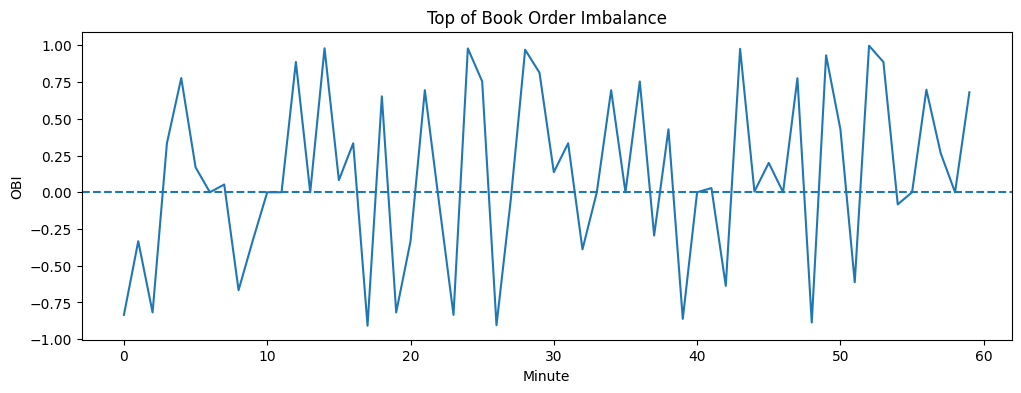

In [133]:
plt.figure(figsize=(12,4))

plt.plot(
    price_bar["OBI"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Top of Book Order Imbalance"
)

plt.xlabel(
    "Minute"
)

plt.ylabel(
    "OBI"
)

plt.show()

In [134]:
#ΔPt​=α+β1​ΔPt−1​+β2​BDIt−1​+β3​OBIt−1​+ϵt​


var_df = pd.concat(
    [
        price_bar["mid_price_avg"],
        lambda_df["birth_death_imbalance"],
        price_bar["OBI"]
    ],
    axis=1
)


var_df.columns = [

    "price",
    "BDI",
    "OBI"

]


var_df["price_change"] = (

    var_df["price"]

    -

    var_df["price"].shift(1)

)


var_df = var_df.dropna()

In [135]:
from statsmodels.tsa.api import VAR


model = VAR(

    var_df[
        [
            "price_change",
            "BDI",
            "OBI"
        ]
    ]

)


results = model.fit(1)


print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 27, Jul, 2026
Time:                     23:53:19
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -6.62773
Nobs:                     58.0000    HQIC:                  -6.88797
Log likelihood:          -30.3285    FPE:                0.000864492
AIC:                     -7.05403    Det(Omega_mle):     0.000707734
--------------------------------------------------------------------
Results for equation price_change
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.054134         0.072327            0.748           0.454
L1.price_change         0.259894         0.130021            1.999           0.046
L1.BDI                  0.117077         0.24

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
